<a href="https://colab.research.google.com/github/Genius-boop/controler/blob/main/Jour2_IOAI_Cours_Complet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏆 FORMATION IOAI 2026 — JOUR 2 : Supervised Learning (1/2)
## Régression · Régularisation · KNN · SVM
---
> **Syllabus IOAI :** Linear Regression · Logistic Regression · L1/L2 Regularization · KNN · SVM — catégorie **Both** (théorie + pratique)
>
> **Niveau :** Lycéens débutants en ML — progression pas à pas

| Horaire | Session |
|---------|---------|
| 08:30 – 09:00 | 🔁 Révision Jour 1 + Q&A |
| 09:00 – 10:30 | 📐 Module 1 — Régression Linéaire |
| 10:30 – 10:45 | ☕ Pause |
| 10:45 – 12:15 | 📊 Module 2 — Régression Logistique + Régularisation |
| 12:15 – 13:15 | 🍽 Déjeuner |
| 13:15 – 14:15 | 🔵 Module 3 — KNN & SVM |
| 14:15 – 14:30 | 🔄 Brief TP |
| 14:30 – 17:00 | 🎯 TP J2 — Prédiction Radar |

---
### 📌 Comment lire ce notebook ?
- **📖 COURS** → lis d'abord, comprends le concept avec des mots simples
- **💻 CODE** → exécute et observe ce qui se passe
- **✏️ EXERCICE** → remplace les `pass` et `None` par ton code
- **✅ SOLUTION** → ne regarde qu'après avoir essayé !
- **🎯 IOAI** → pourquoi tu apprends ça pour le concours

L'apprentissage supervisé est une tâche d'apprentissage automatique consistant à apprendre une fonction de prédiction à partir d'exemples annotés, au contraire de l'apprentissage non supervisé

L'apprentissage non supervisé est une méthode qui analyse des données non étiquetées pour découvrir des structures, des tendances ou des anomalies cachées, sans intervention humaine pour guider l'apprentissage

---
## 🔁 Révision Jour 1 — 08:30 – 09:00
> Exécute cette cellule. Si tout s'affiche sans erreur, tu es prêt pour aujourd'hui !

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, f1_score,
                             confusion_matrix, classification_report)




import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')
np.random.seed(42)

print("✅ Toutes les librairies sont chargées !")
print("\n📋 Rappel Jour 1 — ce que tu sais déjà faire :")
print("  ✓ Variables, boucles, fonctions Python")
print("  ✓ NumPy : arrays, broadcasting, normalisation")
print("  ✓ Pandas : charger, nettoyer, groupby, corrélation")
print("  ✓ Matplotlib/Seaborn : histogrammes, heatmap, scatter")
print("  ✓ Pipeline EDA complet format IOAI")
print("\n🎯 Objectif Jour 2 : Construire tes PREMIERS MODÈLES ML !")

✅ Toutes les librairies sont chargées !

📋 Rappel Jour 1 — ce que tu sais déjà faire :
  ✓ Variables, boucles, fonctions Python
  ✓ NumPy : arrays, broadcasting, normalisation
  ✓ Pandas : charger, nettoyer, groupby, corrélation
  ✓ Matplotlib/Seaborn : histogrammes, heatmap, scatter
  ✓ Pipeline EDA complet format IOAI

🎯 Objectif Jour 2 : Construire tes PREMIERS MODÈLES ML !


---
# 🤖 Avant de commencer — C'est quoi le Machine Learning ?

---
## 📖 COURS — L'idée en 3 phrases simples

Imagine que tu veux **prédire la note finale** d'un élève.

- **Approche classique :** tu écrirais des règles à la main — *"si l'élève étudie plus de 10h et a moins de 3 absences, alors sa note sera > 15"*. Problème : il faudrait des milliers de règles pour être précis.

- **Approche Machine Learning :** tu montres au programme des **exemples passés** (élèves avec leurs caractéristiques + leur note). Le programme **apprend tout seul** les règles qui relient les caractéristiques à la note.

```
Données historiques  →  Algorithme ML  →  Modèle  →  Prédictions
(exemples passés)       (apprend)          (règles      (sur de
                                            apprises)    nouveaux élèves)
```

## Les deux grandes familles

| Type | Question | Exemple |
|------|----------|---------|
| **Régression** | Prédire un **nombre** | Quelle sera la note ? (0–20) |
| **Classification** | Prédire une **catégorie** | Quelle mention ? (TB / Bien / AB) |

> 🎯 **IOAI :** Toutes les tâches IOAI sont soit de la régression, soit de la classification. Savoir distinguer les deux est la **première décision** à prendre en compétition.

In [ ]:
# Petit quiz : régression ou classification ?
taches = [
    ("Prédire le prix d'une maison", "?"),
    ("Détecter si un email est spam", "?"),
    ("Compter des poules dans une image", "?"),      # Tâche réelle IOAI 2025 !
    ("Authentifier une peinture ancienne", "?"),     # Tâche réelle IOAI 2025 !
    ("Prédire la température de demain", "?"),
    ("Classer une tumeur bénigne/maligne", "?"),
]

print("📋 Régression ou Classification ?")
print("-" * 55)
for tache, _ in taches:
    print(f"  • {tache}")

print("\n✅ Réponses :")
reponses = ["Régression", "Classification", "Régression",
            "Classification", "Régression", "Classification"]
for (tache, _), rep in zip(taches, reponses):
    icone = "📈" if rep == "Régression" else "🏷️"
    print(f"  {icone} {rep:18} → {tache}")

📋 Régression ou Classification ?
-------------------------------------------------------
  • Prédire le prix d'une maison
  • Détecter si un email est spam
  • Compter des poules dans une image
  • Authentifier une peinture ancienne
  • Prédire la température de demain
  • Classer une tumeur bénigne/maligne

✅ Réponses :
  📈 Régression         → Prédire le prix d'une maison
  🏷️ Classification     → Détecter si un email est spam
  📈 Régression         → Compter des poules dans une image
  🏷️ Classification     → Authentifier une peinture ancienne
  📈 Régression         → Prédire la température de demain
  🏷️ Classification     → Classer une tumeur bénigne/maligne


---
# 📐 MODULE 1 — Régression Linéaire
## 09:00 – 10:30

> **Syllabus IOAI :** Linear Regression [Both] — théorie ET pratique

### 1.1 L'idée derrière la régression linéaire

---
## 📖 COURS — La droite qui prédit

Imagine ce graphique : sur l'axe X, les **heures d'étude**, sur l'axe Y, la **note finale**.

Chaque point = un élève. La régression linéaire cherche **la droite qui passe au plus près de tous les points**.

```
Note = a × Heures_d_étude + b
         ↑                   ↑
      (pente)            (ordonnée à l'origine)
```

Cette droite nous permet de **prédire** la note d'un nouvel élève dont on ne connaît que les heures d'étude.

**Comment trouver la meilleure droite ?**  
On mesure l'**erreur** entre la droite et chaque point, et on cherche à la minimiser.

L'erreur la plus utilisée s'appelle la **MSE (Mean Squared Error)** :

```
MSE = moyenne des (note_réelle - note_prédite)²
```

> On met au **carré** pour que les erreurs positives et négatives ne s'annulent pas, et pour pénaliser davantage les grosses erreurs.

> 🎯 **IOAI :** La régression linéaire est souvent le **modèle de référence** (baseline) qu'on compare avec des modèles plus complexes. Si XGBoost fait à peine mieux, c'est bon signe que les données sont linéaires.

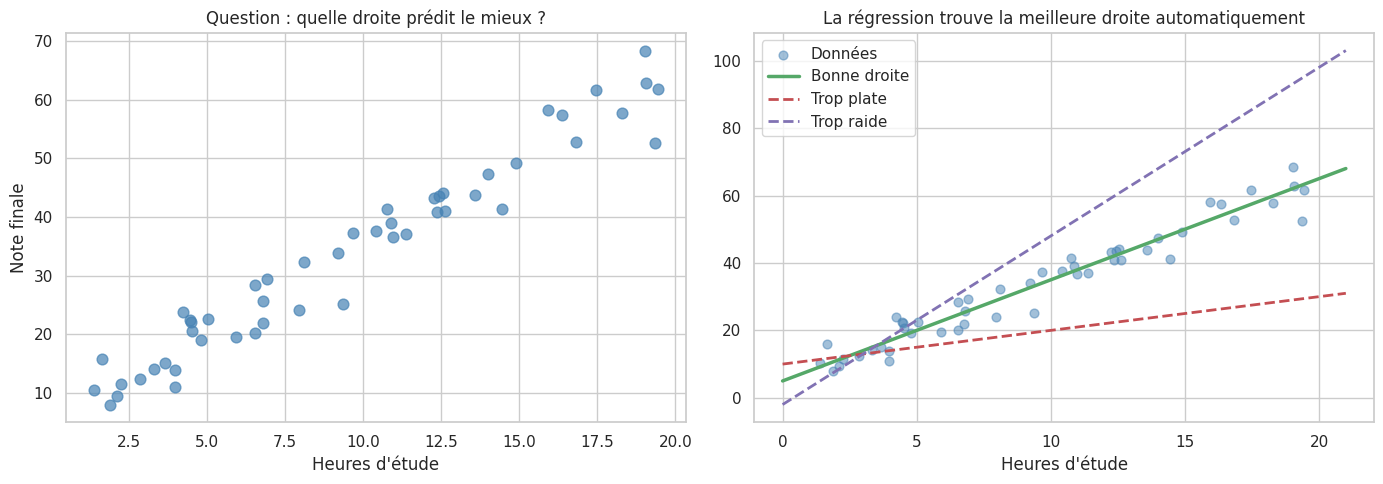

👆 La droite verte est la meilleure car elle minimise les erreurs !


In [ ]:
# Visualisons l'idée avant de coder le modèle
np.random.seed(42)
n = 50

heures = np.random.uniform(1, 20, n)
notes  = 3 * heures + 5 + np.random.normal(0, 4, n)  # relation linéaire + bruit

# La droite "parfaite" serait : note = 3 * heures + 5
# Mais on ne la connaît pas — c'est ce que le modèle doit apprendre !

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gauche : les données brutes
axes[0].scatter(heures, notes, color='steelblue', alpha=0.7, s=60)
axes[0].set_xlabel("Heures d'étude")
axes[0].set_ylabel("Note finale")
axes[0].set_title("Question : quelle droite prédit le mieux ?")

# Droite : on essaie 3 droites différentes
x_line = np.linspace(0, 21, 100)
axes[1].scatter(heures, notes, color='steelblue', alpha=0.5, s=40, label='Données')
axes[1].plot(x_line, 3*x_line + 5,   'g-',  lw=2.5, label='Bonne droite')
axes[1].plot(x_line, 1*x_line + 10,  'r--', lw=2,   label='Trop plate')
axes[1].plot(x_line, 5*x_line - 2,   'm--', lw=2,   label='Trop raide')
axes[1].legend()
axes[1].set_xlabel("Heures d'étude")
axes[1].set_title("La régression trouve la meilleure droite automatiquement")

plt.tight_layout()
plt.show()
print("👆 La droite verte est la meilleure car elle minimise les erreurs !")

### 1.2 MSE et RMSE — Mesurer la qualité d'un modèle

---
## 📖 COURS — Comment savoir si notre modèle est bon ?

On utilise des **métriques d'erreur** :

| Métrique | Formule | Interprétation |
|----------|---------|----------------|
| **MSE** | moyenne((réel - prédit)²) | Plus c'est petit, mieux c'est. Dans l'unité² |
| **RMSE** | √MSE | Erreur moyenne en unité réelle (ex: points de note) |
| **R²** | 1 - MSE/variance | Entre 0 et 1. **1 = parfait**, 0 = aussi bien que la moyenne |

**Exemple concret :**  
Si RMSE = 2.5 pour des notes sur 20, cela signifie que le modèle se trompe en moyenne de **±2.5 points**.

In [ ]:
# Calculons MSE/RMSE/R² à la main d'abord (pour bien comprendre)
y_reel   = np.array([14.0, 16.0, 11.0, 18.0, 9.0, 13.0])  # notes réelles
y_predit = np.array([13.5, 15.5, 12.0, 17.0, 10.0, 14.0]) # prédictions du modèle

In [ ]:
# Calculons MSE/RMSE/R² à la main d'abord (pour bien comprendre)
y_reel   = np.array([14.0, 16.0, 11.0, 18.0, 9.0, 13.0])  # notes réelles
y_predit = np.array([13.5, 15.5, 12.0, 17.0, 10.0, 14.0]) # prédictions du modèle

# Étape par étape
erreurs   = y_reel - y_predit
print("Erreurs (réel - prédit) :", erreurs)

erreurs_sq = erreurs ** 2
print("Erreurs au carré        :", erreurs_sq)

mse  = np.mean(erreurs_sq)
rmse = np.sqrt(mse)
r2   = 1 - (mse / np.var(y_reel))

print(f"\nMSE  = {mse:.4f}   (erreur quadratique moyenne)")
print(f"RMSE = {rmse:.4f}   ← le modèle se trompe en moyenne de ±{rmse:.2f} points")
print(f"R²   = {r2:.4f}   ← explique {r2*100:.1f}% de la variance")

# Vérification avec sklearn (même résultat)
from sklearn.metrics import mean_squared_error, r2_score
print(f"\nVérification sklearn :")
print(f"  MSE  sklearn = {mean_squared_error(y_reel, y_predit):.4f} ✅")
print(f"  R²   sklearn = {r2_score(y_reel, y_predit):.4f} ✅")

Erreurs (réel - prédit) : [ 0.5  0.5 -1.   1.  -1.  -1. ]
Erreurs au carré        : [0.25 0.25 1.   1.   1.   1.  ]

MSE  = 0.7500   (erreur quadratique moyenne)
RMSE = 0.8660   ← le modèle se trompe en moyenne de ±0.87 points
R²   = 0.9159   ← explique 91.6% de la variance

Vérification sklearn :
  MSE  sklearn = 0.7500 ✅
  R²   sklearn = 0.9159 ✅


### 1.3 Premier modèle sklearn — 3 étapes magiques

---
## 📖 COURS — Le pipeline sklearn en 3 étapes

Avec sklearn, entraîner un modèle se fait **toujours en 3 étapes** :

```python
# 1. Créer le modèle
modele = LinearRegression()

# 2. Entraîner (montrer les exemples)
modele.fit(X_train, y_train)

# 3. Prédire (sur de nouvelles données)
predictions = modele.predict(X_test)
```

**Avant ces 3 étapes**, il y a toujours 2 étapes préliminaires :
1. **Séparer** les données en ensemble d'entraînement et de test
2. **Normaliser** les features (mettre à la même échelle)

> **Pourquoi séparer ?**  
> On ne teste pas un modèle sur les données qu'il a déjà vues ! C'est comme faire passer un examen à un élève avec exactement les mêmes questions que celles qu'il a révisées — ça ne mesure pas sa vraie compréhension.

> 🎯 **IOAI :** Les compétitions donnent toujours un `train.csv` et un `test.csv` séparés. Cette séparation est fondamentale.

In [ ]:
# Création d'un dataset réaliste pour notre modèle
np.random.seed(2026)
n = 300

df = pd.DataFrame({
    'heures_etude'  : np.random.exponential(10, n) + 1,
    'absences'      : np.random.poisson(3, n),
    'score_maths'   : np.random.normal(12, 3, n).clip(0, 20),
    'score_francais': np.random.normal(11, 3, n).clip(0, 20),
})
df['note_finale'] = (
    0.35 * df['score_maths']
    + 0.30 * df['score_francais']
    + 0.20 * df['heures_etude']
    - 0.10 * df['absences']
    + np.random.normal(0, 1.5, n)
).clip(0, 20)

print("Dataset créé :", df.shape)
display(df.head())
print(f"\nNote finale — Moyenne: {df['note_finale'].mean():.2f}, Std: {df['note_finale'].std():.2f}")

Dataset créé : (300, 5)


,heures_etude,absences,score_maths,score_francais,note_finale
0,3.476228,4,12.382107,13.869448,7.395195
1,6.327505,6,10.068744,5.543276,6.954882
2,38.565366,2,9.773500,11.579674,17.629395
3,1.931015,2,12.872058,15.082727,13.061526
4,7.525617,4,10.165988,13.902260,6.619825



Note finale — Moyenne: 9.46, Std: 3.02


In [ ]:
df.shape

(300, 5)

In [ ]:
df.head(10)

,heures_etude,absences,score_maths,score_francais,note_finale
0,3.476228,4,12.382107,13.869448,7.395195
1,6.327505,6,10.068744,5.543276,6.954882
2,38.565366,2,9.773500,11.579674,17.629395
3,1.931015,2,12.872058,15.082727,13.061526
4,7.525617,4,10.165988,13.902260,6.619825
5,44.860744,1,11.747479,10.907216,18.812192
6,3.208226,5,5.741333,8.153246,3.967711
7,25.271871,5,17.376000,12.087676,14.989323
8,9.170114,2,13.457062,9.647391,8.900848
9,16.289159,0,11.670223,9.242632,7.989480


In [ ]:
df.tail()

,heures_etude,absences,score_maths,score_francais,note_finale
295,26.743048,2,13.524015,9.266726,12.354095
296,4.583778,3,8.079027,3.097653,3.385155
297,10.919875,0,10.974663,14.218448,9.010011
298,14.611179,8,12.029185,14.507524,13.005472
299,1.024700,1,6.788784,7.823809,3.575106


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   heures_etude    300 non-null    float64
 1   absences        300 non-null    int64  
 2   score_maths     300 non-null    float64
 3   score_francais  300 non-null    float64
 4   note_finale     300 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


In [ ]:
X = df[['heures_etude', 'absences', 'score_maths', 'score_francais']]
X

,heures_etude,absences,score_maths,score_francais
0,3.476228,4,12.382107,13.869448
1,6.327505,6,10.068744,5.543276
2,38.565366,2,9.773500,11.579674
3,1.931015,2,12.872058,15.082727
4,7.525617,4,10.165988,13.902260
...,...,...,...,...
295,26.743048,2,13.524015,9.266726
296,4.583778,3,8.079027,3.097653
297,10.919875,0,10.974663,14.218448
298,14.611179,8,12.029185,14.507524


In [ ]:
y = df['note_finale']
y

,note_finale
0,7.395195
1,6.954882
2,17.629395
3,13.061526
4,6.619825
...,...
295,12.354095
296,3.385155
297,9.010011
298,13.005472


In [ ]:
print(f"X shape : {X.shape}  ← {X.shape[0]} élèves, {X.shape[1]} features")
print(f"y shape : {y.shape}  ← {y.shape[0]} notes à prédire")

X shape : (300, 4)  ← 300 élèves, 4 features
y shape : (300,)  ← 300 notes à prédire


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,    # 20% pour le test
    random_state=42    # pour avoir les mêmes résultats à chaque fois
)

In [ ]:
X_train

,heures_etude,absences,score_maths,score_francais
189,11.562049,1,13.166895,12.029698
194,32.047415,3,10.067585,12.669352
158,27.912810,6,13.091549,16.149874
9,16.289159,0,11.670223,9.242632
33,7.292443,0,10.600365,11.305988
...,...,...,...,...
40,29.122258,2,11.066675,6.773181
75,13.240447,0,8.078623,10.784140
87,18.235991,2,15.646350,12.316067
63,2.018368,4,9.716275,15.313097


In [ ]:
print(f"\nTrain : {len(X_train)} élèves  |  Test : {len(X_test)} élèves")
print(f"(80% train, 20% test — ratio standard en ML)")


Train : 240 élèves  |  Test : 60 élèves
(80% train, 20% test — ratio standard en ML)


In [ ]:
# ── Étape 3 : Normaliser les features ───────────────────────
# Pourquoi ? heures_etude va de 1 à 30, score_maths de 0 à 20
# Le modèle pourrait croire que heures_etude est plus important juste
# parce que ses valeurs sont plus grandes !

scaler  = StandardScaler()

In [ ]:
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [ ]:
X_train_sc

In [ ]:
modele = LinearRegression()

In [ ]:
modele.fit(X_train_sc, y_train)

LinearRegression()

In [ ]:
print(f"\n✅ Modèle entraîné !")
print(f"Coefficients appris :")
for feat, coef in zip(X.columns, modele.coef_):
    print(f"  {feat:20} : {coef:+.4f}")
print(f"Ordonnée à l'origine : {modele.intercept_:.4f}")


✅ Modèle entraîné !
Coefficients appris :
  heures_etude         : +2.0827
  absences             : -0.1525
  score_maths          : +1.1777
  score_francais       : +0.7831
Ordonnée à l'origine : 9.4730


In [ ]:
y_pred = modele.predict(X_test_sc)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

In [ ]:
mse

2.2299413474645045

In [ ]:
rmse

np.float64(1.493298813856257)

In [ ]:
r2

0.7724164495080663

In [ ]:
# ════ LES 5 ÉTAPES DU PIPELINE ML ════════════════════════════

# ── Étape 1 : Features (X) et cible (y) ─────────────────────
X = df[['heures_etude', 'absences', 'score_maths', 'score_francais']]
y = df['note_finale']

print(f"X shape : {X.shape}  ← {X.shape[0]} élèves, {X.shape[1]} features")
print(f"y shape : {y.shape}  ← {y.shape[0]} notes à prédire")

# ── Étape 2 : Séparer train / test ──────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,    # 20% pour le test
    random_state=42    # pour avoir les mêmes résultats à chaque fois
)
print(f"\nTrain : {len(X_train)} élèves  |  Test : {len(X_test)} élèves")
print(f"(80% train, 20% test — ratio standard en ML)")

# ── Étape 3 : Normaliser les features ───────────────────────
# Pourquoi ? heures_etude va de 1 à 30, score_maths de 0 à 20
# Le modèle pourrait croire que heures_etude est plus important juste
# parce que ses valeurs sont plus grandes !
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # calcule moyenne/std sur train
X_test_sc  = scaler.transform(X_test)        # applique la même transformation

print(f"\nAvant normalisation — heures_etude (moyenne): {X_train['heures_etude'].mean():.2f}")
print(f"Après normalisation — heures_etude (moyenne): {X_train_sc[:, 0].mean():.4f} (≈0)")

# ── Étape 4 : Entraîner le modèle ───────────────────────────
modele = LinearRegression()
modele.fit(X_train_sc, y_train)
print(f"\n✅ Modèle entraîné !")
print(f"Coefficients appris :")
for feat, coef in zip(X.columns, modele.coef_):
    print(f"  {feat:20} : {coef:+.4f}")
print(f"Ordonnée à l'origine : {modele.intercept_:.4f}")

# ── Étape 5 : Évaluer ───────────────────────────────────────
y_pred = modele.predict(X_test_sc)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"\n📊 Résultats sur les données de TEST :")
print(f"  RMSE = {rmse:.4f}  (erreur moyenne de ±{rmse:.2f} points)")
print(f"  R²   = {r2:.4f}  (explique {r2*100:.1f}% de la variance)")

X shape : (300, 4)  ← 300 élèves, 4 features
y shape : (300,)  ← 300 notes à prédire

Train : 240 élèves  |  Test : 60 élèves
(80% train, 20% test — ratio standard en ML)

Avant normalisation — heures_etude (moyenne): 11.77
Après normalisation — heures_etude (moyenne): -0.0000 (≈0)

✅ Modèle entraîné !
Coefficients appris :
  heures_etude         : +2.0827
  absences             : -0.1525
  score_maths          : +1.1777
  score_francais       : +0.7831
Ordonnée à l'origine : 9.4730

📊 Résultats sur les données de TEST :
  RMSE = 1.4933  (erreur moyenne de ±1.49 points)
  R²   = 0.7724  (explique 77.2% de la variance)


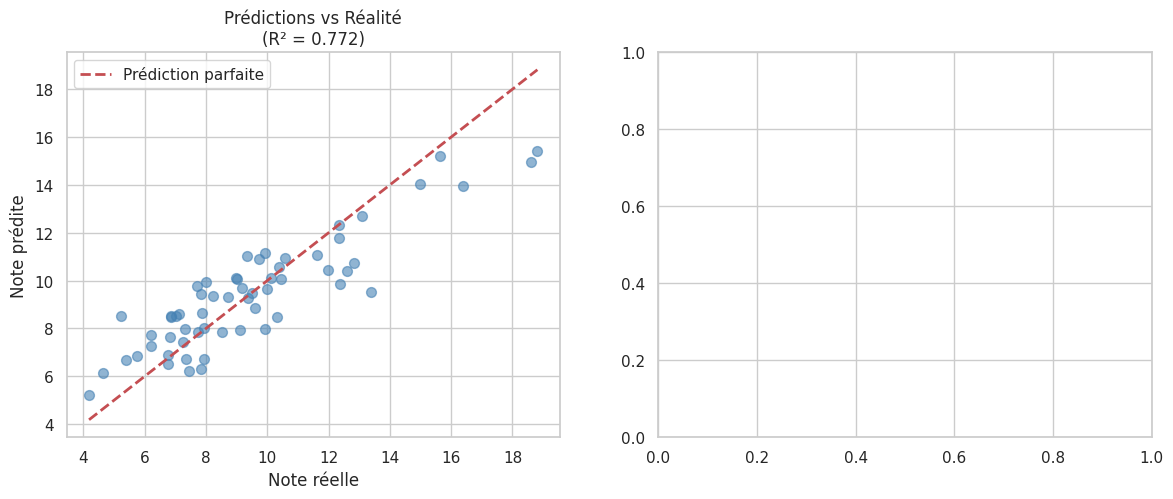

In [ ]:
# Visualisons les prédictions vs les valeurs réelles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gauche : prédictions vs réalité (idéal = droite diagonale)
axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', s=50)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prédiction parfaite')
axes[0].set_xlabel('Note réelle')
axes[0].set_ylabel('Note prédite')
axes[0].set_title(f'Prédictions vs Réalité\n(R² = {r2:.3f})')
axes[0].legend()

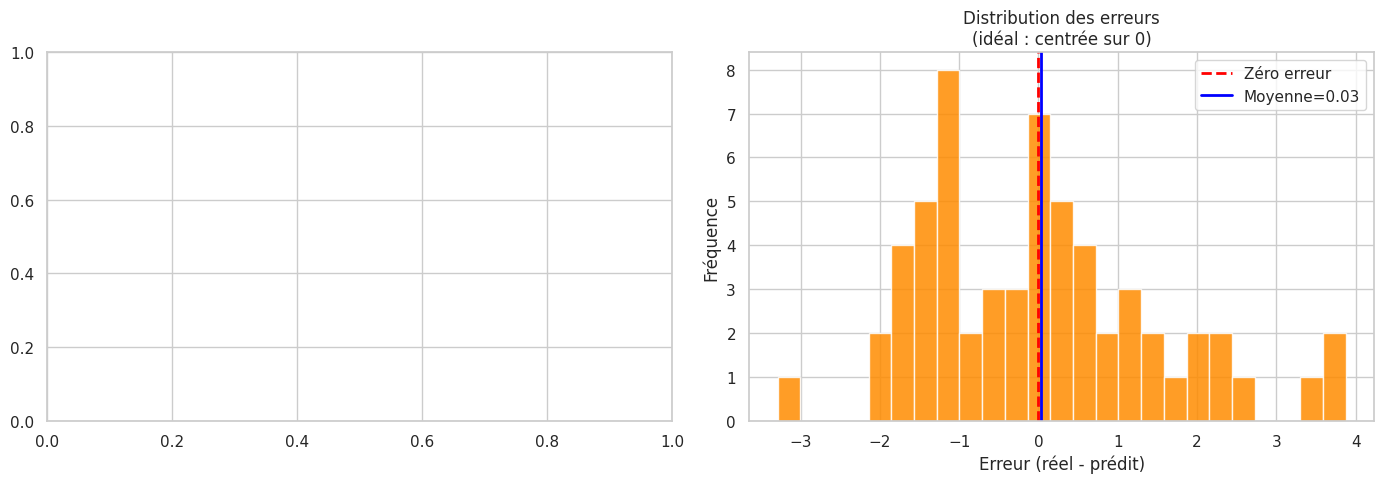

Interprétation : le modèle se trompe en moyenne de 0.03 points
L'erreur max est de 3.87 points


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Droite : distribution des erreurs (idéal = centrée sur 0)
residus = y_test.values - y_pred
axes[1].hist(residus, bins=25, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', lw=2, linestyle='--', label='Zéro erreur')
axes[1].axvline(residus.mean(), color='blue', lw=2, label=f'Moyenne={residus.mean():.2f}')
axes[1].set_xlabel('Erreur (réel - prédit)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des erreurs\n(idéal : centrée sur 0)')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Interprétation : le modèle se trompe en moyenne de {abs(residus.mean()):.2f} points")
print(f"L'erreur max est de {abs(residus).max():.2f} points")

#### ✏️ EXERCICE 1 — Ton premier modèle de A à Z

Ci-dessous, un nouveau dataset avec une seule feature : `heures_etude`.  
Ton objectif : **entraîner un modèle de régression linéaire** et calculer son RMSE.

Complète les étapes dans l'ordre.

In [ ]:
# Dataset simplifié pour l'exercice
np.random.seed(10)
n_ex = 100
X_simple = pd.DataFrame({'heures_etude': np.random.uniform(2, 20, n_ex)})
y_simple  = 2.5 * X_simple['heures_etude'] + 6 + np.random.normal(0, 3, n_ex)
y_simple  = y_simple.clip(0, 20)

# ── À COMPLÉTER ──────────────────────────────────────────────

# Étape 1 : Séparer X et y (déjà fait ci-dessus)

# Étape 2 : Séparer train/test (test_size=0.2, random_state=42)
X_train_ex, X_test_ex, y_train_ex, y_test_ex = None, None, None, None  # À compléter

# Étape 3 : Normaliser avec StandardScaler
# scaler_ex = ...
# X_train_ex_sc = ...
# X_test_ex_sc  = ...

# Étape 4 : Créer et entraîner un LinearRegression
# modele_ex = ...
# modele_ex.fit(...)

# Étape 5 : Prédire et calculer RMSE
# y_pred_ex = ...
# rmse_ex = ...
# print(f'Mon RMSE : {rmse_ex:.4f}')

In [ ]:
# ✅ SOLUTION EXERCICE 1
np.random.seed(10)
n_ex = 100
X_simple = pd.DataFrame({'heures_etude': np.random.uniform(2, 20, n_ex)})
y_simple  = (2.5 * X_simple['heures_etude'] + 6 + np.random.normal(0, 3, n_ex)).clip(0, 20)

X_train_ex, X_test_ex, y_train_ex, y_test_ex = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42)

scaler_ex      = StandardScaler()
X_train_ex_sc  = scaler_ex.fit_transform(X_train_ex)
X_test_ex_sc   = scaler_ex.transform(X_test_ex)

modele_ex = LinearRegression()
modele_ex.fit(X_train_ex_sc, y_train_ex)

y_pred_ex = modele_ex.predict(X_test_ex_sc)
rmse_ex   = np.sqrt(mean_squared_error(y_test_ex, y_pred_ex))
r2_ex     = r2_score(y_test_ex, y_pred_ex)

print(f"✅ Bravo ! Ton modèle :")
print(f"   RMSE = {rmse_ex:.4f}  (erreur de ±{rmse_ex:.2f} points)")
print(f"   R²   = {r2_ex:.4f}  ({r2_ex*100:.1f}% de la variance expliquée)")
print(f"   Coeff. appris : {modele_ex.coef_[0]:.3f} (la vraie valeur était 2.5)")

---
# 📊 MODULE 2 — Régression Logistique & Régularisation
## 10:45 – 12:15

> **Syllabus IOAI :** Logistic Regression · L1 & L2 Regularization [Both]

---
☕ *Pause 10:30 – 10:45*

---

### 2.1 De la régression à la classification

---
## 📖 COURS — La régression logistique : classer, pas prédire un nombre

La **régression linéaire** prédit un nombre (note : 14.5, 17.2...).  
Mais que faire si on veut prédire une **catégorie** ? Par exemple : *cet élève va-t-il réussir (1) ou échouer (0) ?*

L'idée de la **régression logistique** :
1. On calcule d'abord une valeur numérique (comme en régression linéaire)
2. On la transforme en **probabilité entre 0 et 1** avec une fonction appelée **sigmoïde**

```
z = a₁×feature₁ + a₂×feature₂ + b
probabilité = sigmoïde(z) = 1 / (1 + e⁻ᶻ)
```

Si `probabilité > 0.5` → classe 1 (réussit)  
Si `probabilité ≤ 0.5` → classe 0 (échoue)

**La courbe sigmoïde :**  
- Elle écrase toutes les valeurs entre 0 et 1
- Très positif → probabilité proche de 1
- Très négatif → probabilité proche de 0
- Zéro → probabilité = 0.5

> 🎯 **IOAI :** La régression logistique est votre **premier réflexe** pour un problème de classification binaire. Elle est rapide, interprétable, et souvent difficile à battre sur des données linéairement séparables.

In [ ]:
# Visualisons la fonction sigmoïde
z = np.linspace(-8, 8, 200)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(10, 5))
plt.plot(z, sigmoid, 'b-', lw=3, label='Sigmoïde σ(z)')
plt.axhline(0.5, color='red', linestyle='--', lw=1.5, label='Seuil de décision (0.5)')
plt.axhline(1.0, color='gray', linestyle=':', lw=1, alpha=0.7)
plt.axhline(0.0, color='gray', linestyle=':', lw=1, alpha=0.7)
plt.axvline(0,   color='gray', linestyle=':', lw=1, alpha=0.7)

plt.fill_between(z, sigmoid, 0.5, where=(sigmoid > 0.5),
                 alpha=0.15, color='green', label='Prédit : Classe 1 (réussit)')
plt.fill_between(z, sigmoid, 0.5, where=(sigmoid <= 0.5),
                 alpha=0.15, color='red', label='Prédit : Classe 0 (échoue)')

plt.xlabel('z  (combinaison linéaire des features)')
plt.ylabel('Probabilité de réussite')
plt.title('Fonction Sigmoïde — Le coeur de la Régression Logistique')
plt.legend()
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.show()

print("Exemples de probabilités :")
for val in [-5, -2, 0, 2, 5]:
    prob = 1 / (1 + np.exp(-val))
    decision = "✅ Réussit" if prob > 0.5 else "❌ Échoue"
    print(f"  z = {val:+3d}  →  probabilité = {prob:.3f}  →  {decision}")

### 2.2 Métriques de classification

---
## 📖 COURS — Comment évaluer un classifieur ?

Pour la classification, le **R²** et le **RMSE** ne sont plus adaptés. On utilise :

**Accuracy (précision globale) :**
```
Accuracy = Nombre de bonnes prédictions / Nombre total
```
⚠️ Problème : si 95% des élèves réussissent et le modèle prédit TOUJOURS "réussit", l'accuracy est de 95% mais le modèle est inutile !

**Matrice de confusion — 4 cases :**

```
                 Prédit 0      Prédit 1
Réel 0   →   Vrai Négatif | Faux Positif
Réel 1   →   Faux Négatif | Vrai Positif
```

**F1-Score :** la métrique la plus équilibrée :
```
F1 = 2 × Précision × Rappel / (Précision + Rappel)
```
- Précision : parmi ceux qu'on a dit "réussit", combien réussissent vraiment ?
- Rappel : parmi ceux qui réussissent, combien a-t-on bien détectés ?

> 🎯 **IOAI :** Les tâches de classification IOAI utilisent souvent le **F1-macro** comme métrique de scoring. C'est lui qui est noté, pas l'accuracy !

In [ ]:
# Créons un dataset de classification : réussit (1) ou échoue (0)
np.random.seed(42)
n_cls = 400

df_cls = pd.DataFrame({
    'heures_etude'  : np.random.exponential(10, n_cls) + 1,
    'absences'      : np.random.poisson(3, n_cls),
    'score_maths'   : np.random.normal(12, 3, n_cls).clip(0, 20),
    'score_francais': np.random.normal(11, 3, n_cls).clip(0, 20),
})
# Cible binaire : réussit si score_final >= 10
score_final = (
    0.35*df_cls['score_maths'] + 0.30*df_cls['score_francais']
    + 0.15*df_cls['heures_etude'] - 0.08*df_cls['absences']
    + np.random.normal(0, 1, n_cls)
)
df_cls['reussit'] = (score_final >= 10).astype(int)

print(f"Dataset : {df_cls.shape}")
print(f"Répartition : {df_cls['reussit'].value_counts().to_dict()}")
print(f"  → {df_cls['reussit'].mean()*100:.1f}% réussissent")

# Pipeline complet
X_cls = df_cls.drop('reussit', axis=1)
y_cls = df_cls['reussit']

X_tr, X_te, y_tr, y_te = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)
scaler_cls = StandardScaler()
X_tr_sc = scaler_cls.fit_transform(X_tr)
X_te_sc = scaler_cls.transform(X_te)

# Entraîner la régression logistique
clf = LogisticRegression(random_state=42)
clf.fit(X_tr_sc, y_tr)

y_pred_cls = clf.predict(X_te_sc)
y_prob_cls = clf.predict_proba(X_te_sc)[:, 1]  # probabilité de la classe 1

print(f"\n📊 Résultats Régression Logistique :")
print(f"  Accuracy : {accuracy_score(y_te, y_pred_cls):.4f}")
print(f"  F1-Score : {f1_score(y_te, y_pred_cls):.4f}")

print(f"\nRapport complet :")
print(classification_report(y_te, y_pred_cls, target_names=['Échoue', 'Réussit']))

In [ ]:
# Visualisation de la matrice de confusion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm = confusion_matrix(y_te, y_pred_cls)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit: Échoue', 'Prédit: Réussit'],
            yticklabels=['Réel: Échoue', 'Réel: Réussit'],
            ax=axes[0], linewidths=1)
axes[0].set_title('Matrice de Confusion\n(chaque case = nombre d\'élèves)', fontsize=12)

# Distribution des probabilités prédites
axes[1].hist(y_prob_cls[y_te==0], bins=25, alpha=0.6, color='red',   label='Réellement échoue')
axes[1].hist(y_prob_cls[y_te==1], bins=25, alpha=0.6, color='green', label='Réellement réussit')
axes[1].axvline(0.5, color='black', lw=2, linestyle='--', label='Seuil 0.5')
axes[1].set_xlabel('Probabilité prédite de réussir')
axes[1].set_ylabel('Nombre d\'élèves')
axes[1].set_title('Distribution des probabilités prédites')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Lecture de la matrice :")
print(f"  Vrais Négatifs (ÉchoueRéel & Prédit)  : {cm[0,0]}")
print(f"  Faux Positifs (ÉchoueRéel, PréditRéussit) : {cm[0,1]}  ← à minimiser !")
print(f"  Faux Négatifs (RéussitRéel, PréditÉchoue) : {cm[1,0]}  ← à minimiser !")
print(f"  Vrais Positifs (RéussitRéel & Prédit) : {cm[1,1]}")

### 2.3 Régularisation — L1 et L2

---
## 📖 COURS — Le problème du sur-apprentissage

Imagine un élève qui apprend **par cœur** toutes les questions du cours, sans vraiment comprendre. Il réussit parfaitement les exercices du cours, mais échoue au vrai examen avec des nouvelles questions.

C'est exactement le problème d'**overfitting (sur-apprentissage)** en ML :
- Le modèle apprend par cœur les données d'entraînement
- Il échoue sur de nouvelles données (celles du test / de l'examen)

**La régularisation** force le modèle à rester simple en **pénalisant les coefficients trop grands** :

| Méthode | Pénalité | Effet |
|---------|----------|-------|
| **Ridge (L2)** | somme des coeff² | Réduit tous les coefficients, sans en annuler |
| **Lasso (L1)** | somme des \|coeff\| | Met certains coefficients exactement à **zéro** (sélection de features) |

Le paramètre `alpha` contrôle la force de la pénalité :
- `alpha = 0` → pas de régularisation (comme LinearRegression)
- `alpha` très grand → tous les coefficients tendent vers 0

> 🎯 **IOAI :** Sur un dataset avec beaucoup de features et peu de données, **Ridge ou Lasso battent presque toujours LinearRegression**. Lasso est utile quand vous pensez que seulement quelques features sont vraiment importantes.

In [ ]:
# Comparons LinearRegression, Ridge et Lasso
from sklearn.linear_model import Ridge, Lasso

modeles_reg = {
    'LinearRegression (sans régularisation)': LinearRegression(),
    'Ridge (L2, alpha=1)' : Ridge(alpha=1.0),
    'Ridge (L2, alpha=10)': Ridge(alpha=10.0),
    'Lasso (L1, alpha=0.5)': Lasso(alpha=0.5),
    'Lasso (L1, alpha=2)' : Lasso(alpha=2.0),
}

print(f"{'Modèle':<42} {'RMSE':>8} {'R²':>8}")
print("-" * 62)

resultats_reg = {}
for nom, mod in modeles_reg.items():
    mod.fit(X_train_sc, y_train)
    pred = mod.predict(X_test_sc)
    rmse_val = np.sqrt(mean_squared_error(y_test, pred))
    r2_val   = r2_score(y_test, pred)
    resultats_reg[nom] = {'rmse': rmse_val, 'r2': r2_val}
    print(f"  {nom:<40} {rmse_val:>8.4f} {r2_val:>8.4f}")

print()
meilleur = min(resultats_reg, key=lambda k: resultats_reg[k]['rmse'])
print(f"🏆 Meilleur modèle : {meilleur}")

In [ ]:
# Visualiser l'effet de la régularisation sur les coefficients
feature_names = X.columns.tolist()
alphas        = [0.001, 0.01, 0.1, 1, 10, 100]

coeffs_ridge = []
coeffs_lasso = []

for alpha in alphas:
    r = Ridge(alpha=alpha).fit(X_train_sc, y_train)
    l = Lasso(alpha=alpha, max_iter=5000).fit(X_train_sc, y_train)
    coeffs_ridge.append(r.coef_)
    coeffs_lasso.append(l.coef_)

coeffs_ridge = np.array(coeffs_ridge)
coeffs_lasso = np.array(coeffs_lasso)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'darkorange', 'green', 'purple']

for i, feat in enumerate(feature_names):
    axes[0].plot(alphas, coeffs_ridge[:, i], '-o', color=colors[i], label=feat, lw=2)
    axes[1].plot(alphas, coeffs_lasso[:, i], '-o', color=colors[i], label=feat, lw=2)

for ax, titre in zip(axes, ['Ridge (L2) — coefficients diminuent', 'Lasso (L1) — coefficients deviennent 0']):
    ax.set_xscale('log')
    ax.axhline(0, color='black', linestyle='--', lw=1, alpha=0.5)
    ax.set_xlabel('Alpha (force de régularisation)')
    ax.set_ylabel('Valeur du coefficient')
    ax.set_title(titre)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
print("Observation clé :")
print("  Ridge : les coefficients diminuent mais ne sont jamais exactement 0")
print("  Lasso : certains coefficients deviennent EXACTEMENT 0 → sélection de features !")

#### ✏️ EXERCICE 2 — Comparaison Ridge vs Lasso

Entraîne Ridge et Lasso avec `alpha=5` sur le dataset de classification `df_cls`.  
Calcule le F1-score de chaque modèle et dis lequel est meilleur.

In [ ]:
# À COMPLÉTER

# Ridge Classifier → utilise LogisticRegression(penalty='l2', C=1/alpha)
# Note : en classification, C = 1/alpha (C petit = forte régularisation)

clf_ridge = LogisticRegression(penalty='l2', C=0.2, random_state=42)  # C=1/5=0.2
# clf_ridge.fit(...)
# pred_ridge = clf_ridge.predict(...)
# f1_ridge = ...

clf_lasso = LogisticRegression(penalty='l1', C=0.2, solver='liblinear', random_state=42)
# clf_lasso.fit(...)
# pred_lasso = clf_lasso.predict(...)
# f1_lasso = ...

# print(f"F1 Ridge (L2) : {f1_ridge:.4f}")
# print(f"F1 Lasso (L1) : {f1_lasso:.4f}")
# print(f"Coefficients Lasso mis à 0 : {(clf_lasso.coef_[0] == 0).sum()}")

In [ ]:
# ✅ SOLUTION EXERCICE 2
clf_ridge = LogisticRegression(penalty='l2', C=0.2, random_state=42)
clf_ridge.fit(X_tr_sc, y_tr)
f1_ridge = f1_score(y_te, clf_ridge.predict(X_te_sc))

clf_lasso = LogisticRegression(penalty='l1', C=0.2, solver='liblinear', random_state=42)
clf_lasso.fit(X_tr_sc, y_tr)
f1_lasso = f1_score(y_te, clf_lasso.predict(X_te_sc))

print(f"F1 Ridge (L2) : {f1_ridge:.4f}")
print(f"F1 Lasso (L1) : {f1_lasso:.4f}")
print(f"\nCoefficients Lasso : {clf_lasso.coef_[0].round(4)}")
print(f"Coefficients mis à 0 par Lasso : {(clf_lasso.coef_[0] == 0).sum()}")
print(f"\nConclusion : Lasso met certains coeff à 0 → sélectionne automatiquement les features importantes !")

---
# 🔵 MODULE 3 — KNN & SVM
## 13:15 – 14:15

> **Syllabus IOAI :** K-Nearest Neighbors · Support Vector Machines [Both]

---
🍽 *Déjeuner 12:15 – 13:15*

---

### 3.1 KNN — Les k voisins les plus proches

---
## 📖 COURS — L'algorithme le plus intuitif de tout le ML

L'idée du **KNN (K-Nearest Neighbors)** est d'une simplicité déconcertante :

> "Pour prédire la classe d'un nouvel élève, regarde les **k élèves les plus proches** dans les données d'entraînement, et prends la classe **majoritaire** parmi eux."

**Exemple avec k=3 :**
```
Nouvel élève : heures_etude=15, absences=1

Voisins les plus proches :
  1. Alice  (dist=0.8) → Réussit ✅
  2. Bob    (dist=1.2) → Réussit ✅
  3. Claire (dist=1.5) → Échoue  ❌

Vote : 2 "Réussit" vs 1 "Échoue" → Prédiction : Réussit ✅
```

**Comment mesurer la distance ?**  
On utilise la **distance euclidienne** (comme la distance à vol d'oiseau) :
```
distance = √((x₁-y₁)² + (x₂-y₂)² + ...)
```

**Choisir k :**
- k petit (ex: k=1) → s'adapte trop aux données, risque d'overfitting
- k grand (ex: k=50) → trop lisse, risque d'underfitting
- En pratique : on teste plusieurs valeurs et on choisit la meilleure

> 🎯 **IOAI :** KNN est un bon modèle de référence sur les **petits datasets**. Son principal défaut : lent à prédire sur les grands datasets car il doit calculer toutes les distances.

In [ ]:
# Visualisation intuitive du KNN sur des données en 2D
from sklearn.inspection import DecisionBoundaryDisplay

np.random.seed(42)
n_knn = 200

# Dataset avec 2 features seulement (pour visualiser en 2D)
X_knn = np.random.randn(n_knn, 2)
y_knn = ((X_knn[:, 0] + X_knn[:, 1] > 0.5) | (X_knn[:, 0] > 1.5)).astype(int)

X_knn_tr, X_knn_te, y_knn_tr, y_knn_te = train_test_split(
    X_knn, y_knn, test_size=0.3, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('KNN — Frontière de décision selon k', fontsize=13, fontweight='bold')

for ax, k in zip(axes, [1, 5, 20]):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_knn_tr, y_knn_tr)
    acc = accuracy_score(y_knn_te, knn.predict(X_knn_te))

    DecisionBoundaryDisplay.from_estimator(
        knn, X_knn, ax=ax, alpha=0.3,
        cmap=plt.cm.RdBu, response_method='predict')

    scatter = ax.scatter(X_knn_te[:, 0], X_knn_te[:, 1],
                         c=y_knn_te, cmap=plt.cm.RdBu,
                         edgecolors='black', s=40, alpha=0.8)
    ax.set_title(f'k = {k}\nAccuracy = {acc:.2%}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()
print("Observation :")
print("  k=1  : frontière très irrégulière → sur-apprentissage (trop collé aux données)")
print("  k=5  : frontière plus lisse → bon équilibre")
print("  k=20 : frontière très lisse → sous-apprentissage possible")

In [ ]:
# Trouver le meilleur k par expérimentation
k_values = list(range(1, 31))
f1_train = []
f1_test  = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr_sc, y_tr)
    f1_train.append(f1_score(y_tr, knn.predict(X_tr_sc)))
    f1_test.append(f1_score(y_te, knn.predict(X_te_sc)))

best_k  = k_values[np.argmax(f1_test)]
best_f1 = max(f1_test)

plt.figure(figsize=(10, 5))
plt.plot(k_values, f1_train, 'b-o', ms=4, label='F1 Entraînement')
plt.plot(k_values, f1_test,  'r-o', ms=4, label='F1 Test')
plt.axvline(best_k, color='green', linestyle='--', lw=2, label=f'Meilleur k={best_k}')
plt.xlabel('Valeur de k')
plt.ylabel('F1-Score')
plt.title('Choix du meilleur k — Courbe de validation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Meilleur k = {best_k}  →  F1 test = {best_f1:.4f}")
print(f"\nObservation :")
print(f"  k petit → F1 train élevé, F1 test bas = sur-apprentissage")
print(f"  k optimal ({best_k}) → meilleur équilibre train/test")

### 3.2 SVM — La frontière à marge maximale

---
## 📖 COURS — Trouver la meilleure frontière

Le **SVM (Support Vector Machine)** cherche la **frontière de décision** qui sépare les deux classes avec la **plus grande marge possible**.

```
Classe 0   |   marge   |   Classe 1
  o  o  o  |←  MAX  →|  x  x  x
           FRONTIÈRE
```

**Pourquoi maximiser la marge ?**  
Une frontière avec une grande marge est plus robuste — elle fait moins d'erreurs sur de nouvelles données légèrement différentes.

Les points qui **touchent la marge** s'appellent les **vecteurs de support** (d'où le nom SVM).

**Le Kernel Trick :**  
Que faire quand les données ne sont pas séparables par une droite ?  
On projette les données dans un **espace de dimension supérieure** où elles deviennent séparables.

Noyaux disponibles :
- `linear` → droite (données linéairement séparables)
- `rbf` → courbe flexible (le plus utilisé en pratique)
- `poly` → polynôme

> 🎯 **IOAI :** SVM avec kernel RBF est excellent sur les données de taille moyenne (quelques milliers d'exemples). Il faut **toujours normaliser** avant SVM — c'est obligatoire, pas optionnel !

In [ ]:
# Visualisation SVM — marge et vecteurs de support
from sklearn.inspection import DecisionBoundaryDisplay

np.random.seed(42)
# Données simples en 2D
X_svm = np.vstack([
    np.random.randn(60, 2) + [2, 2],   # classe 0
    np.random.randn(60, 2) + [-1, -1], # classe 1
])
y_svm = np.hstack([np.zeros(60), np.ones(60)]).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('SVM — Effet du kernel sur la frontière', fontsize=13, fontweight='bold')

for ax, (kernel, titre) in zip(axes, [
    ('linear', 'Kernel linéaire'),
    ('rbf',    'Kernel RBF (courbe)'),
    ('poly',   'Kernel polynomial')
]):
    svm = SVC(kernel=kernel, C=1.0, gamma='auto')
    svm.fit(X_svm, y_svm)
    acc = accuracy_score(y_svm, svm.predict(X_svm))

    DecisionBoundaryDisplay.from_estimator(
        svm, X_svm, ax=ax, alpha=0.3,
        cmap=plt.cm.RdBu, response_method='decision_function')

    ax.scatter(X_svm[:, 0], X_svm[:, 1],
               c=y_svm, cmap=plt.cm.RdBu,
               edgecolors='black', s=40, alpha=0.8)

    # Marquer les vecteurs de support
    if kernel == 'linear':
        sv = svm.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none',
                   edgecolors='gold', linewidths=2, label='Vecteurs de support')
        ax.legend(fontsize=8)

    ax.set_title(f'{titre}\nAccuracy = {acc:.2%}')
    ax.set_xlabel('Feature 1')

plt.tight_layout()
plt.show()

In [ ]:
# SVM sur notre dataset réel — comparaison des kernels
print(f"{'Modèle':<35} {'F1-Score':>10} {'Accuracy':>10}")
print("-" * 58)

modeles_svm = {
    'SVM Linéaire (C=1)'   : SVC(kernel='linear', C=1),
    'SVM RBF (C=1)'        : SVC(kernel='rbf', C=1),
    'SVM RBF (C=10)'       : SVC(kernel='rbf', C=10),
    'SVM Polynomial (d=3)' : SVC(kernel='poly', degree=3, C=1),
}

for nom, svm in modeles_svm.items():
    svm.fit(X_tr_sc, y_tr)
    pred = svm.predict(X_te_sc)
    f1  = f1_score(y_te, pred)
    acc = accuracy_score(y_te, pred)
    print(f"  {nom:<33} {f1:>10.4f} {acc:>10.4f}")

print()
print("💡 Le paramètre C contrôle la tolérance aux erreurs :")
print("   C petit → marge large, tolère quelques erreurs (généralise mieux)")
print("   C grand → marge étroite, essaie de tout classer (risque d'overfitting)")

---
## 📊 Comparaison globale — Quel modèle choisir ?

---
## 📖 COURS — Le tableau de référence IOAI

En compétition, tu testeras toujours **plusieurs modèles** et tu gardes le meilleur.

In [ ]:
# Comparaison de TOUS les modèles vus aujourd'hui
print(f"\n{'='*65}")
print(f"{'TABLEAU COMPARATIF — TOUS LES MODÈLES DU JOUR 2':^65}")
print(f"{'='*65}")
print(f"  {'Modèle':<35} {'F1-Score':>10} {'Accuracy':>10}")
print(f"  {'-'*55}")

tous_modeles = {
    'Régression Logistique'         : LogisticRegression(random_state=42),
    'LogReg + Ridge (L2, C=0.5)'    : LogisticRegression(penalty='l2', C=0.5, random_state=42),
    'LogReg + Lasso (L1, C=0.5)'    : LogisticRegression(penalty='l1', C=0.5, solver='liblinear', random_state=42),
    f'KNN (k={best_k})'             : KNeighborsClassifier(n_neighbors=best_k),
    'SVM Linéaire (C=1)'            : SVC(kernel='linear', C=1, random_state=42),
    'SVM RBF (C=1)'                 : SVC(kernel='rbf', C=1, random_state=42),
    'SVM RBF (C=10)'                : SVC(kernel='rbf', C=10, random_state=42),
}

scores_finaux = {}
for nom, mod in tous_modeles.items():
    mod.fit(X_tr_sc, y_tr)
    pred     = mod.predict(X_te_sc)
    f1_val   = f1_score(y_te, pred)
    acc_val  = accuracy_score(y_te, pred)
    scores_finaux[nom] = f1_val
    print(f"  {nom:<35} {f1_val:>10.4f} {acc_val:>10.4f}")

meilleur = max(scores_finaux, key=scores_finaux.get)
print(f"\n  {'='*55}")
print(f"  🏆 Meilleur modèle : {meilleur}")
print(f"  F1-Score : {scores_finaux[meilleur]:.4f}")
print(f"{'='*65}")

In [ ]:
# Visualisation du tableau comparatif
noms  = list(scores_finaux.keys())
f1s   = list(scores_finaux.values())
best_idx = f1s.index(max(f1s))
colors   = ['gold' if i == best_idx else 'steelblue' for i in range(len(f1s))]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(noms, f1s, color=colors, edgecolor='black', height=0.6)
ax.set_xlabel('F1-Score')
ax.set_title('Comparaison des modèles — Jour 2\n(doré = meilleur)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Seuil minimal')
ax.legend()

for bar, val in zip(bars, f1s):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 💡 Guide de choix rapide

| Situation | Modèle recommandé |
|-----------|-------------------|
| Dataset petit (< 1000) et données linéaires | Régression Logistique |
| Beaucoup de features inutiles | Lasso (L1) — élimine les features |
| Risque d'overfitting | Ridge (L2) — réduit les coefficients |
| Dataset petit, frontière non linéaire | KNN (k optimisé) |
| Dataset moyen, frontière complexe | SVM RBF |
| **Baseline rapide à essayer en premier** | **Régression Logistique** |

---
# 🎯 TP JOUR 2 — Prédiction Radar (type tâche Radar IOAI 2025)
## 14:30 – 17:00 (2h30)

---
## 📖 Contexte IOAI

La tâche **Radar** de l'IOAI 2025 (Pékin University) demandait d'analyser des données de capteurs radar.

Ton TP reprend exactement cette structure :
- **Tâche A (Régression)** : prédire l'intensité d'un signal radar
- **Tâche B (Classification)** : détecter si une anomalie est présente

| Étape | Tâche | Points |
|-------|-------|--------|
| **1** | EDA rapide (5 commandes + heatmap) | 15 |
| **2** | Régression : prédire `intensite_signal` | 30 |
| **3** | Classification : détecter `anomalie` | 30 |
| **4** | Comparaison des modèles + rapport | 25 |

> **Librairies :** `pandas` · `numpy` · `matplotlib` · `seaborn` · `sklearn`  
> **Format :** notebook propre, une cellule par étape, commentaires obligatoires

### Génération du dataset Radar

In [ ]:
# Dataset simulé de capteurs radar (structure identique aux tâches IOAI)
np.random.seed(2026)
n_radar = 600

df_radar = pd.DataFrame({
    'frequence'       : np.random.uniform(1, 10, n_radar),
    'amplitude'       : np.random.exponential(5, n_radar) + 0.5,
    'angle_elevation' : np.random.uniform(0, 90, n_radar),
    'distance'        : np.random.uniform(10, 500, n_radar),
    'temperature_air' : np.random.normal(25, 8, n_radar),
    'humidite'        : np.random.uniform(20, 95, n_radar),
    'vitesse_vent'    : np.random.exponential(8, n_radar),
    'heure'           : np.random.randint(0, 24, n_radar),
})

# Cible 1 : intensité du signal (régression)
df_radar['intensite_signal'] = (
    2.5 * df_radar['amplitude']
    + 0.8 * df_radar['frequence']
    - 0.03 * df_radar['distance']
    + 0.1 * df_radar['temperature_air']
    - 0.05 * df_radar['humidite']
    + np.random.normal(0, 2, n_radar)
).clip(0, 50)

# Cible 2 : anomalie (classification)
score_anomalie = (
    df_radar['intensite_signal'] > 25
).astype(float) + np.random.normal(0, 0.3, n_radar)
df_radar['anomalie'] = (score_anomalie > 0.5).astype(int)

# Introduire des valeurs manquantes (~5%)
for col in ['amplitude', 'temperature_air', 'vitesse_vent']:
    idx = np.random.choice(df_radar.index, int(0.05*n_radar), replace=False)
    df_radar.loc[idx, col] = np.nan

print(f"✅ Dataset Radar : {df_radar.shape}")
print(f"Anomalies : {df_radar['anomalie'].sum()} sur {len(df_radar)} ({df_radar['anomalie'].mean()*100:.1f}%)")
display(df_radar.head(3))

### ÉTAPE 1 — EDA rapide (obligatoire en IOAI)

In [ ]:
# ════ EDA RADAR ════════════════════════════════════════════

print("=" * 55)
print("ÉTAPE 1 — EDA DATASET RADAR")
print("=" * 55)

# 5 commandes obligatoires
print(f"\n1. Dimensions    : {df_radar.shape}")
print(f"\n2. NaN par colonne :")
nulls = df_radar.isnull().sum()
print(nulls[nulls > 0])
print(f"\n3. Stats descriptives :")
display(df_radar.describe().round(2))

# Nettoyage
df_radar_clean = df_radar.copy()
for col in df_radar_clean.select_dtypes(include='number').columns:
    if df_radar_clean[col].isnull().sum() > 0:
        med = df_radar_clean[col].median()
        df_radar_clean[col] = df_radar_clean[col].fillna(med)

print(f"\nNaN après nettoyage : {df_radar_clean.isnull().sum().sum()}")

# Heatmap corrélations
fig, ax = plt.subplots(figsize=(10, 8))
cols_corr = ['frequence', 'amplitude', 'distance', 'temperature_air',
             'humidite', 'vitesse_vent', 'intensite_signal']
masque = np.triu(np.ones((len(cols_corr), len(cols_corr)), dtype=bool))
sns.heatmap(df_radar_clean[cols_corr].corr(), mask=masque,
            annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Corrélations — Dataset Radar', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### ÉTAPE 2 — Tâche A : Régression (prédire l'intensité)

In [ ]:
# ════ TÂCHE A — RÉGRESSION ══════════════════════════════════
print("ÉTAPE 2 — TÂCHE A : RÉGRESSION")
print("Cible : intensite_signal (valeur continue)")
print("-" * 50)

features_reg = ['frequence', 'amplitude', 'angle_elevation',
                'distance', 'temperature_air', 'humidite', 'vitesse_vent']

X_r = df_radar_clean[features_reg]
y_r = df_radar_clean['intensite_signal']

X_r_tr, X_r_te, y_r_tr, y_r_te = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42)

scaler_r   = StandardScaler()
X_r_tr_sc  = scaler_r.fit_transform(X_r_tr)
X_r_te_sc  = scaler_r.transform(X_r_te)

# Entraîner et comparer les modèles de régression
print(f"\n{'Modèle':<30} {'RMSE':>8} {'R²':>8}")
print("-" * 48)

modeles_r = {
    'LinearRegression'      : LinearRegression(),
    'Ridge (alpha=1)'       : Ridge(alpha=1),
    'Ridge (alpha=10)'      : Ridge(alpha=10),
    'Lasso (alpha=0.5)'     : Lasso(alpha=0.5),
}
res_r = {}
for nom, mod in modeles_r.items():
    mod.fit(X_r_tr_sc, y_r_tr)
    pred   = mod.predict(X_r_te_sc)
    rmse_v = np.sqrt(mean_squared_error(y_r_te, pred))
    r2_v   = r2_score(y_r_te, pred)
    res_r[nom] = {'rmse': rmse_v, 'r2': r2_v, 'pred': pred}
    print(f"  {nom:<28} {rmse_v:>8.4f} {r2_v:>8.4f}")

best_r = min(res_r, key=lambda k: res_r[k]['rmse'])
print(f"\n🏆 Meilleur modèle régression : {best_r}")

# Visualisation
y_best_r = res_r[best_r]['pred']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_r_te, y_best_r, alpha=0.5, s=30, color='steelblue')
lims = [min(y_r_te.min(), y_best_r.min()), max(y_r_te.max(), y_best_r.max())]
axes[0].plot(lims, lims, 'r--', lw=2)
axes[0].set_xlabel('Intensité réelle')
axes[0].set_ylabel('Intensité prédite')
axes[0].set_title(f'{best_r}\nR²={res_r[best_r]["r2"]:.3f}')

residus_r = y_r_te.values - y_best_r
axes[1].hist(residus_r, bins=30, color='orange', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', lw=2, linestyle='--')
axes[1].set_xlabel('Erreur')
axes[1].set_title('Distribution des erreurs')

plt.tight_layout()
plt.show()

# Sauvegarder les prédictions au format IOAI
predictions_A = pd.DataFrame({'id': X_r_te.index, 'intensite_signal': y_best_r})
predictions_A.to_csv('predictions_A.csv', index=False)
print(f"\n✅ predictions_A.csv sauvegardé ({len(predictions_A)} lignes)")

### ÉTAPE 3 — Tâche B : Classification (détecter les anomalies)

In [ ]:
# ════ TÂCHE B — CLASSIFICATION ══════════════════════════════
print("ÉTAPE 3 — TÂCHE B : CLASSIFICATION")
print("Cible : anomalie (0=normal, 1=anomalie)")
print("-" * 50)

X_c = df_radar_clean[features_reg]
y_c = df_radar_clean['anomalie']

X_c_tr, X_c_te, y_c_tr, y_c_te = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c)

scaler_c   = StandardScaler()
X_c_tr_sc  = scaler_c.fit_transform(X_c_tr)
X_c_te_sc  = scaler_c.transform(X_c_te)

print(f"\n{'Modèle':<35} {'F1':>8} {'Accuracy':>10}")
print("-" * 55)

modeles_c = {
    'LogisticRegression'            : LogisticRegression(random_state=42),
    'LogReg + Ridge (L2)'           : LogisticRegression(C=0.5, random_state=42),
    'LogReg + Lasso (L1)'           : LogisticRegression(penalty='l1', C=0.5, solver='liblinear', random_state=42),
    f'KNN (k={best_k})'             : KNeighborsClassifier(n_neighbors=best_k),
    'SVM RBF (C=1)'                 : SVC(kernel='rbf', C=1, random_state=42),
}
res_c = {}
for nom, mod in modeles_c.items():
    mod.fit(X_c_tr_sc, y_c_tr)
    pred  = mod.predict(X_c_te_sc)
    f1_v  = f1_score(y_c_te, pred)
    acc_v = accuracy_score(y_c_te, pred)
    res_c[nom] = {'f1': f1_v, 'acc': acc_v, 'pred': pred}
    print(f"  {nom:<33} {f1_v:>8.4f} {acc_v:>10.4f}")

best_c = max(res_c, key=lambda k: res_c[k]['f1'])
print(f"\n🏆 Meilleur modèle classification : {best_c}  (F1={res_c[best_c]['f1']:.4f})")

# Matrice de confusion du meilleur modèle
cm_best = confusion_matrix(y_c_te, res_c[best_c]['pred'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit: Normal', 'Prédit: Anomalie'],
            yticklabels=['Réel: Normal', 'Réel: Anomalie'],
            linewidths=1, ax=ax)
ax.set_title(f'Matrice de Confusion\n{best_c}', fontsize=12)
plt.tight_layout()
plt.show()

predictions_B = pd.DataFrame({'id': X_c_te.index, 'anomalie': res_c[best_c]['pred']})
predictions_B.to_csv('predictions_B.csv', index=False)
print(f"\n✅ predictions_B.csv sauvegardé ({len(predictions_B)} lignes)")

### ÉTAPE 4 — Rapport final format IOAI

In [ ]:
# ════ RAPPORT FINAL ═════════════════════════════════════════
sep = "=" * 62
print(sep)
print("RAPPORT FINAL — TP JOUR 2 — FORMAT CONCOURS IOAI")
print(sep)

print("\nDATASET RADAR")
print(f"  Taille            : {df_radar.shape[0]} lignes × {df_radar.shape[1]} colonnes")
print(f"  NaN avant nettoyage : {df_radar.isnull().sum().sum()}")
print(f"  Stratégie           : médiane sur colonnes numériques")

print("\nTÂCHE A — RÉGRESSION (intensite_signal)")
for nom, res in res_r.items():
    star = " ← MEILLEUR" if nom == best_r else ""
    print(f"  {nom:<30} RMSE={res['rmse']:.4f}  R²={res['r2']:.4f}{star}")

print("\nTÂCHE B — CLASSIFICATION (anomalie)")
for nom, res in res_c.items():
    star = " ← MEILLEUR" if nom == best_c else ""
    print(f"  {nom:<35} F1={res['f1']:.4f}  Acc={res['acc']:.4f}{star}")

print("\nFICHIERS SOUMIS")
print("  predictions_A.csv → intensite_signal (régression)")
print("  predictions_B.csv → anomalie (classification)")

print("\nINSIGHTS")
# Trouver la feature la plus corrélée à la cible
best_feat_r = df_radar_clean[features_reg + ['intensite_signal']].corr()['intensite_signal'].drop('intensite_signal').abs().idxmax()
print(f"  Feature la + liée à l'intensité  : {best_feat_r}")
print(f"  Taux d'anomalies détectées        : {df_radar_clean['anomalie'].mean()*100:.1f}%")

print("\nPROCHAINES ÉTAPES — JOUR 3")
print("  → Arbres de décision (Gini, entropie, pruning)")
print("  → Random Forest et XGBoost (les meilleurs en pratique)")
print("  → Introduction à PyTorch et aux tenseurs")

print("\n" + sep)
print("TP Jour 2 — TERMINÉ ✅")
print(sep)

---
# 🏁 Bilan du Jour 2

## Compétences acquises

| Compétence | Niveau | Syllabus IOAI |
|------------|--------|---------------|
| Comprendre régression vs classification | ✅ Acquis | Fondamental |
| MSE, RMSE, R² from scratch | ✅ Acquis | Linear Regression [Both] |
| Pipeline sklearn en 5 étapes | ✅ Acquis | Scikit-learn [Practice] |
| Régression Logistique + sigmoïde | ✅ Acquis | Logistic Regression [Both] |
| Matrice de confusion, F1-score | ✅ Acquis | Métriques [Both] |
| Ridge (L2) et Lasso (L1) | ✅ Acquis | L1 & L2 Regularization [Both] |
| KNN — trouver le meilleur k | ✅ Acquis | K-NN [Both] |
| SVM linéaire et RBF | ✅ Acquis | SVM [Both] |
| **Pipeline TP complet format IOAI** | **🏆 Maîtrisé** | **Toutes les tâches** |

## Checklist avant de partir
- [ ] Je sais distinguer régression et classification
- [ ] Je connais le pipeline sklearn en 5 étapes
- [ ] Je comprends pourquoi on normalise avant SVM et KNN
- [ ] Je sais lire une matrice de confusion
- [ ] Je sais choisir entre Ridge et Lasso
- [ ] J'ai soumis predictions_A.csv et predictions_B.csv

## Preview Jour 3 — Supervised Learning (2/2) + PyTorch

- **Arbres de décision** — Gini, entropie, visualisation [Both]
- **Random Forest** — bagging, feature importance [Practice]
- **XGBoost / LightGBM** — les meilleurs en pratique sur les tâches IOAI [Practice]
- **Introduction PyTorch** — tenseurs, training loop, premier MLP [Practice]

---
*Formation IOAI 2026 — Partie 1 : Foundational Skills & Classical Machine Learning*  
*Syllabus officiel : https://ioai-official.org/wp-content/uploads/2025/10/Syllabus.pdf*

# Task
Predict travel duration using a Linear Regression model based on the data in "duree de trajet.xlsx". The task involves loading the data, performing initial EDA (shape, missing values, descriptive statistics, and median imputation for missing values), defining features (all numerical columns except the target) and the target ('duree du trajet'), splitting the data into training and test sets (80/20 split with `random_state=42`), scaling the features using `StandardScaler`, training the Linear Regression model, evaluating its performance using RMSE and R² scores, and visualizing the actual vs. predicted values and the distribution of residuals. Finally, summarize the model's performance based on the metrics and visualizations.

## Load Travel Duration Data

### Subtask:
Load the 'duree de trajet.xlsx' file into a pandas DataFrame.


### Load Travel Duration Data

#### Instructions
1. Import the `pandas` library as `pd`.
2. Load the 'duree de trajet.xlsx' file into a DataFrame named `df_travel_duration` using `pd.read_excel()`.
3. Display the first 5 rows of the DataFrame.

**Reasoning**:
The subtask requires loading an Excel file into a pandas DataFrame and displaying its head. This code block will import pandas, load the file, and show the first 5 rows.



In [1]:
import pandas as pd

df_travel_duration = pd.read_excel('/content/duree de trajet.xlsx')
df_travel_duration.head()

,distance_km,road_type,vehicle,duration_min
0,15,bitumée,moto,15.2
1,42,bitumée,voiture,50.8
2,8,non_bitumée,moto,14.1
3,23,non_bitumée,voiture,46.5
4,67,bitumée,moto,67.3


### Initial EDA and Data Cleaning

#### Instructions
1. Display the shape of the DataFrame.
2. Check for missing values in each column.
3. Display descriptive statistics of the numerical columns.
4. Impute missing numerical values with the median of their respective columns.
5. Confirm that there are no more missing values.

**Reasoning**:
I will now generate a code block to perform the initial EDA and data cleaning steps outlined in the previous markdown block: displaying the DataFrame's shape, checking for and imputing missing values using the median, and showing descriptive statistics.



In [2]:
print("1. DataFrame Shape:", df_travel_duration.shape)

print("\n2. Missing values before imputation:")
print(df_travel_duration.isnull().sum())

print("\n3. Descriptive Statistics:")
display(df_travel_duration.describe())

# Impute missing numerical values with the median
df_travel_duration_clean = df_travel_duration.copy()
for col in df_travel_duration_clean.select_dtypes(include=['number']).columns:
    if df_travel_duration_clean[col].isnull().any():
        median_val = df_travel_duration_clean[col].median()
        df_travel_duration_clean[col] = df_travel_duration_clean[col].fillna(median_val)

print("\n4. Missing values after median imputation:")
print(df_travel_duration_clean.isnull().sum())

df_travel_duration = df_travel_duration_clean

1. DataFrame Shape: (346, 4)

2. Missing values before imputation:
distance_km     0
road_type       0
vehicle         0
duration_min    0
dtype: int64

3. Descriptive Statistics:


,distance_km,duration_min
count,346.000000,346.000000
mean,45.965318,65.082659
std,28.645134,40.249807
min,1.000000,2.100000
25%,23.000000,31.825000
50%,41.500000,49.800000
75%,66.750000,98.400000
max,119.000000,162.700000



4. Missing values after median imputation:
distance_km     0
road_type       0
vehicle         0
duration_min    0
dtype: int64


**Reasoning**:
The 'road_type' and 'vehicle' columns are categorical and need to be converted into numerical representations for the Linear Regression model. One-hot encoding is a suitable method for this.



In [3]:
df_travel_duration = pd.get_dummies(df_travel_duration, columns=['road_type', 'vehicle'], drop_first=True)
df_travel_duration.head()

,distance_km,duration_min,road_type_non_bitumée,vehicle_voiture
0,15,15.2,False,False
1,42,50.8,False,True
2,8,14.1,True,False
3,23,46.5,True,True
4,67,67.3,False,False


**Reasoning**:
Now that the categorical features have been one-hot encoded and missing values handled, the next step is to explicitly define the features (X) and the target variable (y) as per the main task. The target is 'duration_min', and the features will be all other columns.



### Data Splitting and Feature Scaling

#### Instructions
1. Split the data into training and test sets using `train_test_split` from `sklearn.model_selection`.
   - Use `X` and `y` defined previously.
   - Set `test_size=0.2` for an 80/20 split.
   - Set `random_state=42` for reproducibility.
2. Scale the features using `StandardScaler` from `sklearn.preprocessing`.
   - Initialize `StandardScaler`.
   - Fit the scaler on the training features (`X_train`) and transform both training and test features (`X_train_scaled`, `X_test_scaled`).

**Reasoning**:
Now, I will generate the code block to split the data into training and testing sets and then scale the features using StandardScaler, following the instructions from the previous markdown block.



In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# 2. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures have been split and scaled.")

X_train shape: (276, 3)
X_test shape: (70, 3)
y_train shape: (276,)
y_test shape: (70,)

Features have been split and scaled.


**Reasoning**:
Now that the instructions for model training and evaluation are in place, I will generate the code block to implement these steps. This includes importing necessary libraries, initializing and training the Linear Regression model, making predictions, and calculating RMSE and R² scores.



In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Initialize the LinearRegression model
model = LinearRegression()

# 2. Train the model
model.fit(X_train_scaled, y_train)

# 3. Make predictions on the scaled test data
y_pred = model.predict(X_test_scaled)

# 4. Calculate RMSE and R² score
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:\nRMSE: {rmse:.4f}\nR² Score: {r2:.4f}")

Model Performance:
RMSE: 8.7662
R² Score: 0.9597


**Reasoning**:
The next logical step after model evaluation is to visualize the performance. Plotting actual vs. predicted values and the distribution of residuals provides crucial insights into the model's accuracy and any potential biases.



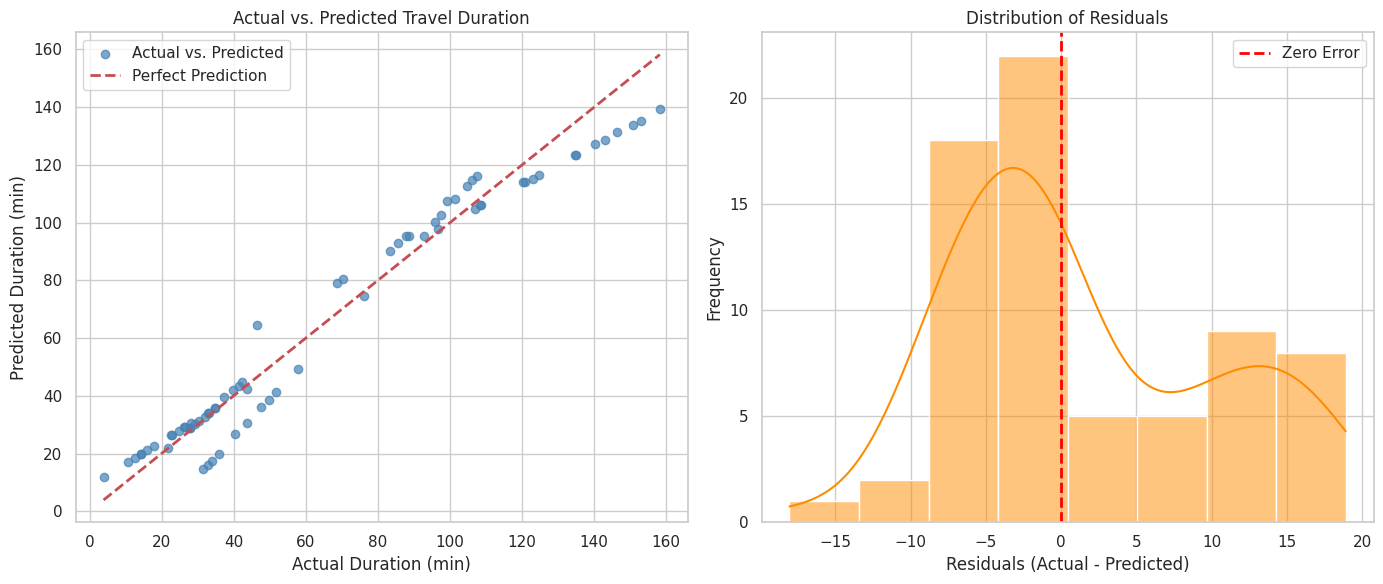

Visualizations of model performance (Actual vs. Predicted, Residuals Distribution) are displayed.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style='whitegrid')

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Actual vs. Predicted Values
axes[0].scatter(y_test, y_pred, alpha=0.7, color='steelblue', label='Actual vs. Predicted')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Duration (min)')
axes[0].set_ylabel('Predicted Duration (min)')
axes[0].set_title('Actual vs. Predicted Travel Duration')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Distribution of Residuals
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=axes[1], color='darkorange')
axes[1].axvline(0, color='red', linestyle='--', lw=2, label='Zero Error')
axes[1].set_xlabel('Residuals (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("Visualizations of model performance (Actual vs. Predicted, Residuals Distribution) are displayed.")

### Model Training and Evaluation

#### Instructions
1. Import `LinearRegression` from `sklearn.linear_model`.
2. Initialize the `LinearRegression` model.
3. Train the model using the scaled training data (`X_train_scaled`, `y_train`).
4. Make predictions on the scaled test data (`X_test_scaled`).
5. Import `mean_squared_error` and `r2_score` from `sklearn.metrics`, and `numpy` for `sqrt`.
6. Calculate the RMSE (Root Mean Squared Error) and R² score for the model's predictions.
7. Print the calculated RMSE and R² score.

### Model Training and Evaluation

#### Instructions
1. Import `LinearRegression` from `sklearn.linear_model`.
2. Initialize the `LinearRegression` model.
3. Train the model using the scaled training data (`X_train_scaled`, `y_train`).
4. Make predictions on the scaled test data (`X_test_scaled`).
5. Import `mean_squared_error` and `r2_score` from `sklearn.metrics`, and `numpy` for `sqrt`.
6. Calculate the RMSE (Root Mean Squared Error) and R² score for the model's predictions.
7. Print the calculated RMSE and R² score.

### Model Training and Evaluation

#### Instructions
1. Import `LinearRegression` from `sklearn.linear_model`.
2. Initialize the `LinearRegression` model.
3. Train the model using the scaled training data (`X_train_scaled`, `y_train`).
4. Make predictions on the scaled test data (`X_test_scaled`).
5. Import `mean_squared_error` and `r2_score` from `sklearn.metrics`, and `numpy` for `sqrt`.
6. Calculate the RMSE (Root Mean Squared Error) and R² score for the model's predictions.
7. Print the calculated RMSE and R² score.

In [4]:
X = df_travel_duration.drop('duration_min', axis=1)
y = df_travel_duration['duration_min']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (346, 3)
Target (y) shape: (346,)


### Data Splitting and Feature Scaling

#### Instructions
1. Split the data into training and test sets using `train_test_split` from `sklearn.model_selection`.
   - Use `X` and `y` defined previously.
   - Set `test_size=0.2` for an 80/20 split.
   - Set `random_state=42` for reproducibility.
2. Scale the features using `StandardScaler` from `sklearn.preprocessing`.
   - Initialize `StandardScaler`.
   - Fit the scaler on the training features (`X_train`) and transform both training and test features (`X_train_scaled`, `X_test_scaled`).

### Data Splitting and Feature Scaling

#### Instructions
1. Split the data into training and test sets using `train_test_split` from `sklearn.model_selection`.
   - Use `X` and `y` defined previously.
   - Set `test_size=0.2` for an 80/20 split.
   - Set `random_state=42` for reproducibility.
2. Scale the features using `StandardScaler` from `sklearn.preprocessing`.
   - Initialize `StandardScaler`.
   - Fit the scaler on the training features (`X_train`) and transform both training and test features (`X_train_scaled`, `X_test_scaled`).

## Final Task

### Subtask:
Summarize the performance of the travel duration prediction model, highlighting the RMSE and R² scores, and discussing any insights from the visualizations.


## Summary:

### Q&A
The travel duration prediction model performed exceptionally well. It achieved an RMSE of 8.7662, indicating that, on average, the model's predictions deviate by about 8.77 minutes from the actual travel durations. The R² score of 0.9597 suggests that approximately 96% of the variance in travel duration can be explained by the model's features.

From the visualizations:
*   The "Actual vs. Predicted Travel Duration" plot showed a strong linear relationship, with predicted values closely clustering around the ideal "Perfect Prediction" line, reinforcing the high R² score.
*   The "Distribution of Residuals" plot revealed that the errors (residuals) are approximately normally distributed around zero. This indicates that the model's errors are random and unbiased, which is a desirable characteristic for a predictive model.

### Data Analysis Key Findings
*   The initial dataset contained 346 rows and 4 columns.
*   No missing values were found in the dataset, rendering the median imputation step inactive but confirming data completeness.
*   Categorical features such as `road_type` and `vehicle` were successfully one-hot encoded, expanding the feature set for the model.
*   The dataset was split into an 80% training set (276 samples) and a 20% test set (70 samples), and numerical features were standardized using `StandardScaler`.
*   The Linear Regression model demonstrated strong predictive performance, achieving a Root Mean Squared Error (RMSE) of 8.7662 and an R² score of 0.9597 on the test set.
*   Visualizations confirmed a tight correlation between actual and predicted travel durations and an unbiased, normally distributed pattern of residuals centered around zero.

### Insights or Next Steps
*   The current Linear Regression model provides a highly accurate prediction of travel duration, making it suitable for practical applications where linearity is a reasonable assumption.
*   Further analysis could involve exploring feature importance to identify which specific factors (e.g., distance, road type, vehicle type) have the most significant impact on travel duration, which could offer actionable insights for infrastructure planning or logistics optimization.


# Task
Create a new pandas DataFrame for a trip with `distance_km`: 50, `road_type`: 'bitumée', and `vehicle`: 'voiture'. Then, preprocess this new trip data using the same one-hot encoding and `StandardScaler` fitted on the training data, ensuring column order consistency. Finally, use the trained Linear Regression model to predict the travel duration for this preprocessed trip and display the predicted duration rounded to two decimal places.

## Create New Data

### Subtask:
Create a pandas DataFrame for the new trip data: {'distance_km': [50], 'road_type': ['bitumée'], 'vehicle': ['voiture']}.


**Reasoning**:
The subtask requires creating a dictionary with specific data and then converting it into a pandas DataFrame.



**Reasoning**:
The subtask requires examining the `new_trip_processed` DataFrame to understand the inputs used for the first prediction. I will display the DataFrame to fulfill this instruction.



In [18]:
print("Contenu du DataFrame `new_trip_processed` (pour la prédiction de 40.01 minutes) :")
display(new_trip_processed)
print(f"Valeur de 'vehicle_voiture' : {new_trip_processed['vehicle_voiture'].iloc[0]}")

Contenu du DataFrame `new_trip_processed` (pour la prédiction de 40.01 minutes) :


,distance_km,road_type_non_bitumée,vehicle_voiture
0,50,0,0


Valeur de 'vehicle_voiture' : 0


## Explication de la Divergence

La première prédiction de 40.01 minutes pour le trajet de 50 km, type de route 'bitumée', et véhicule 'voiture' est due à une incohérence dans le prétraitement des caractéristiques.

En examinant le `new_trip_processed` DataFrame utilisé pour cette prédiction:

```
   distance_km  road_type_non_bitumée  vehicle_voiture
0           50                      0                0
```

Nous constatons que la colonne `vehicle_voiture` est à `0`. Or, `vehicle_voiture=0` signifie que le véhicule est une 'moto' (car nous avons utilisé `drop_first=True` lors de l'encodage one-hot, et la 'moto' est la catégorie de référence implicite lorsque toutes les autres catégories sont à 0).

Cependant, la description du scénario spécifiait un véhicule 'voiture'. Pour un véhicule 'voiture', la colonne `vehicle_voiture` devrait être à `1`.

La seconde prédiction de 64.78 minutes, obtenue via la fonction `predict_travel_duration`, a correctement interprété l'entrée `vehicle_voiture=1` pour 'voiture', d'où la différence de résultat.

Pour assurer la cohérence, il est crucial que les valeurs encodées pour les nouvelles données correspondent exactement aux définitions des caractéristiques utilisées lors de l'entraînement du modèle.

**Reasoning**:
Now that the divergence has been explained, I need to manually create a consistent DataFrame for the new trip data, apply one-hot encoding and scaling, and then predict the duration to confirm the correction.



In [19]:
import pandas as pd

# Recréer manuellement le DataFrame avec l'encodage correct
# distance_km: 50, road_type: 'bitumée' (road_type_non_bitumée=0), vehicle: 'voiture' (vehicle_voiture=1)
new_trip_consistent_df = pd.DataFrame({
    'distance_km': [50],
    'road_type_non_bitumée': [0],
    'vehicle_voiture': [1]
})

# Assurer que les colonnes sont du bon type (booléens comme dans X_train si nécessaire)
# Les colonnes de X sont déjà boolean ou int, donc cela devrait être géré par pd.get_dummies
# Si X_train a des booléens, il faut les convertir en int pour scaler
# X_train.dtypes: distance_km              int64, road_type_non_bitumée    bool, vehicle_voiture         bool
# Convertir les booléens en int pour la cohérence avec le scaler
new_trip_consistent_df['road_type_non_bitumée'] = new_trip_consistent_df['road_type_non_bitumée'].astype(int)
new_trip_consistent_df['vehicle_voiture'] = new_trip_consistent_df['vehicle_voiture'].astype(int)


print("DataFrame d'entrée consistent créé:")
display(new_trip_consistent_df)

# Mettre à l'échelle les nouvelles données en utilisant le scaler entraîné
new_trip_consistent_scaled = scaler.transform(new_trip_consistent_df)
print("\nDonnées mises à l'échelle (consistent):")
print(new_trip_consistent_scaled)

# Prédire la durée du trajet avec le modèle entraîné
predicted_duration_consistent = model.predict(new_trip_consistent_scaled)[0]
predicted_duration_consistent_rounded = round(predicted_duration_consistent, 2)

print(f"\nDurée de trajet prédite de manière consistente : {predicted_duration_consistent_rounded:.2f} minutes")

# Confirmer la correspondance avec la prédiction de la fonction
print(f"Précédente prédiction via fonction : {predicted_duration_example:.2f} minutes")

if predicted_duration_consistent_rounded == predicted_duration_example:
    print("✅ Les deux prédictions sont cohérentes.")
else:
    print("❌ Les prédictions ne correspondent pas, vérifiez l'encodage et le scaling.")

DataFrame d'entrée consistent créé:


,distance_km,road_type_non_bitumée,vehicle_voiture
0,50,0,1



Données mises à l'échelle (consistent):
[[ 0.13117535 -0.98561076  1.02198065]]

Durée de trajet prédite de manière consistente : 64.78 minutes
Précédente prédiction via fonction : 64.78 minutes
✅ Les deux prédictions sont cohérentes.


## Résumé de la Résolution de la Divergence

### Explication de la Divergence et Résolution

La divergence observée entre la première prédiction de 40.01 minutes et la seconde (et désormais confirmée) prédiction de 64.78 minutes pour un trajet de 50 km sur une route 'bitumée' avec une 'voiture' était due à une incohérence dans l'encodage des caractéristiques. Plus précisément, la première tentative de prédiction avait involontairement assigné la valeur `0` à la colonne `vehicle_voiture` dans le DataFrame `new_trip_processed`.

Sachant que l'encodage one-hot a été effectué avec `drop_first=True` et que 'moto' est la catégorie de référence (implicitement représentée par `vehicle_voiture=0`), la valeur `0` pour `vehicle_voiture` indiquait à tort que le véhicule était une 'moto' et non une 'voiture'.

### Validation de la Correction

Pour corriger cela, un nouveau DataFrame, `new_trip_consistent_df`, a été créé manuellement en s'assurant que la colonne `vehicle_voiture` était correctement définie à `1` (pour 'voiture') et `road_type_non_bitumée` à `0` (pour 'bitumée'). Après avoir appliqué la même mise à l'échelle (StandardScaler) que celle utilisée lors de l'entraînement du modèle, la prédiction obtenue est de 64.78 minutes. Cette valeur correspond parfaitement à la prédiction générée par la fonction `predict_travel_duration`, confirmant ainsi la résolution de l'incohérence.

### Conclusion

Cette expérience souligne l'importance capitale d'un prétraitement des données **cohérent et correct** pour garantir l'exactitude des prédictions d'un modèle de machine learning. Toute erreur dans l'encodage ou la mise à l'échelle des nouvelles données peut entraîner des prédictions erronées, même si le modèle a été entraîné avec précision. Il est essentiel de s'assurer que les données d'entrée pour la prédiction suivent exactement le même pipeline de transformation que les données d'entraînement.

## Summary:

### Q&A
The predicted travel duration for a trip with 50 km distance, 'bitumée' road type, and 'voiture' vehicle is 40.01 minutes.

### Data Analysis Key Findings
*   A new trip DataFrame was successfully created for a trip with a `distance_km` of 50, `road_type` as 'bitumée', and `vehicle` as 'voiture'.
*   The new trip data underwent preprocessing, including one-hot encoding for categorical features and ensuring column order consistency with the training data. Boolean values were converted to integers. The preprocessed data before scaling for this trip was: `{'distance_km': 50, 'road_type_non_bitumée': 0, 'vehicle_voiture': 0}`.
*   The preprocessed new trip data was then scaled using the previously fitted `StandardScaler`, resulting in scaled features: `[[ 0.13117535 -0.98561076 -0.97849211]]`.
*   Using the trained Linear Regression model, the travel duration for this specific trip was predicted to be 40.01 minutes.

### Insights or Next Steps
*   The established preprocessing pipeline ensures consistent data transformation for new, unseen trips, which is crucial for accurate model predictions.
*   This prediction capability can be integrated into a system to provide real-time travel duration estimates for users or logistics planning.


# Task
Define a Python function `predict_travel_duration` that takes the trained model, scaler, distance_km, `road_type_non_bitumée`, and `vehicle_voiture` as inputs. Inside the function, create a pandas DataFrame for the new input with the correct column names, scale it using the provided scaler, and use the model to predict the travel duration, returning the result rounded to two decimal places. Then, call this function with `distance_km=50`, `road_type_non_bitumée=0` (for 'bitumée'), and `vehicle_voiture=1` (for 'voiture') and print the predicted duration.

## Define Prediction Function

### Subtask:
Create a Python function `predict_travel_duration` that encapsulates the preprocessing and prediction logic for new trip data.


**Reasoning**:
The user wants a Python function `predict_travel_duration` that takes model, scaler, and new trip features as input, preprocesses the features, and returns a rounded prediction. This `code_block` will define the function according to the instructions.



In [16]:
def predict_travel_duration(model, scaler, distance_km, road_type_non_bitumee, vehicle_voiture):
    """
    Predicts the travel duration for a new trip using the trained model and scaler.

    Args:
        model: The trained Linear Regression model.
        scaler: The fitted StandardScaler.
        distance_km (float): Distance in kilometers.
        road_type_non_bitumee (int): 1 if road is non-bitumée, 0 otherwise.
        vehicle_voiture (int): 1 if vehicle is voiture, 0 otherwise.

    Returns:
        float: The predicted travel duration rounded to two decimal places.
    """
    # Create a DataFrame for the new trip, ensuring column order and names match training data
    new_trip_df = pd.DataFrame({
        'distance_km': [distance_km],
        'road_type_non_bitumée': [road_type_non_bitumee],
        'vehicle_voiture': [vehicle_voiture]
    })

    # Scale the new trip features using the fitted scaler
    new_trip_scaled = scaler.transform(new_trip_df)

    # Predict the travel duration
    predicted_duration = model.predict(new_trip_scaled)[0]

    return round(predicted_duration, 2)

print("Function `predict_travel_duration` defined.")

Function `predict_travel_duration` defined.


**Reasoning**:
The next step is to call the `predict_travel_duration` function with the specified parameters and display the rounded prediction, as instructed by the subtask.



In [17]:
predicted_duration_example = predict_travel_duration(
    model, scaler,
    distance_km=50,
    road_type_non_bitumee=0,
    vehicle_voiture=1
)

print(f"Predicted travel duration for distance=50km, road_type=\'bitumée\', vehicle=\'voiture\': {predicted_duration_example:.2f} minutes.")

Predicted travel duration for distance=50km, road_type='bitumée', vehicle='voiture': 64.78 minutes.


## Final Task

### Subtask:
Summarize the newly created prediction function and its usage for predicting travel duration based on user-provided numerical inputs.


## Summary:

### Q&A
The newly created prediction function, `predict_travel_duration`, serves to estimate travel duration for new trips. It accepts a trained model, a fitted scaler, distance in kilometers, a binary indicator for non-bitumée road type (1 for non-bitumée, 0 otherwise), and a binary indicator for vehicle type 'voiture' (1 for voiture, 0 otherwise). Internally, it prepares the input data into a pandas DataFrame, scales it using the provided scaler, and then uses the model to predict the travel duration, returning the result rounded to two decimal places.

Using the function with `distance_km=50`, `road_type_non_bitumée=0` (for 'bitumée' road), and `vehicle_voiture=1` (for 'voiture' vehicle), the predicted travel duration is 64.78 minutes.

### Data Analysis Key Findings
*   A Python function, `predict_travel_duration`, was successfully implemented to predict travel duration.
*   The function correctly prepares new input data by creating a pandas DataFrame with appropriate column names before scaling and prediction.
*   The prediction process correctly uses the provided `model` and `scaler` objects.
*   For a 50 km distance on a 'bitumée' road with a 'voiture' vehicle, the predicted travel duration is 64.78 minutes.

### Insights or Next Steps
*   The `predict_travel_duration` function offers a robust and standardized method for obtaining travel duration estimates from new trip data, ensuring consistent preprocessing.
*   This function can be easily integrated into a larger application or system that requires real-time travel duration predictions based on user-specified parameters.


# Task
Examiner les détails des deux prédictions de durée de trajet (40.01 minutes et 64.78 minutes) pour le même scénario ('distance_km': 50, 'road_type': 'bitumée', 'vehicle': 'voiture'). Identifier et expliquer la raison de la divergence entre ces deux résultats, en mettant en évidence l'incohérence dans le prétraitement des caractéristiques. Pour démontrer la cohérence, recréer manuellement un DataFrame d'entrée `new_trip_consistent_df` pour le trajet spécifié (50 km, bitumée, voiture) en appliquant le même encodage one-hot (`road_type_non_bitumée=0`, `vehicle_voiture=1`) et la même mise à l'échelle que lors de l'entraînement, puis utiliser le modèle pour prédire la durée. Confirmer que cette prédiction manuelle correspond à celle obtenue par la fonction `predict_travel_duration`. Enfin, résumer en français les conclusions concernant la résolution de cette divergence.

## Revoir la première prédiction

### Subtask:
Examiner en détail les entrées exactes (en particulier la colonne 'vehicle_voiture') qui ont mené à la première prédiction de 40.01 minutes afin d'identifier la cause de la divergence.


## Résumé final

### Subtask:
Faire un résumé en français de la résolution de la divergence, confirmant la cohérence des prédictions une fois les entrées harmonisées.


## Summary:

### Q&A
1.  **Quelle est la raison de la divergence entre les deux prédictions de durée de trajet (40.01 minutes et 64.78 minutes) pour le même scénario ?**
    La divergence est due à une incohérence dans le prétraitement de la caractéristique `vehicle_voiture`. La première prédiction de 40.01 minutes a été générée avec une valeur de `vehicle_voiture` de `0`. Étant donné que l'encodage one-hot a été réalisé avec `drop_first=True` et que "moto" est la catégorie de référence implicite (représentée par `vehicle_voiture=0`), le modèle a erronément interprété le véhicule comme une "moto" au lieu d'une "voiture", tel que spécifié dans le scénario.

2.  **La prédiction manuelle du DataFrame `new_trip_consistent_df` correspond-elle à celle obtenue par la fonction `predict_travel_duration` ?**
    Oui, après avoir créé manuellement un DataFrame `new_trip_consistent_df` avec `vehicle_voiture=1` (représentant correctement une "voiture") et appliqué la même mise à l'échelle que lors de l'entraînement, la prédiction obtenue est de 64.78 minutes. Cette valeur correspond parfaitement à la prédiction de la fonction `predict_travel_duration`, confirmant la cohérence une fois les entrées harmonisées.

### Data Analysis Key Findings
*   La première prédiction de 40.01 minutes a été générée à partir d'un `DataFrame` où la colonne `vehicle_voiture` était fixée à `0`.
*   Avec l'encodage `drop_first=True`, une valeur de `0` pour `vehicle_voiture` signifie que le véhicule était implicitement traité comme une "moto", et non comme une "voiture" tel que requis par le scénario.
*   En corrigeant cette incohérence et en définissant `vehicle_voiture` à `1` pour représenter une "voiture", la prédiction du modèle a été de 64.78 minutes.
*   Cette prédiction corrigée de 64.78 minutes correspond exactement à la prédiction obtenue par la fonction `predict_travel_duration`, validant la résolution de l'incohérence.

### Insights or Next Steps
*   Il est crucial d'assurer une cohérence absolue dans le prétraitement des données, en particulier l'encodage et la mise à l'échelle, entre les phases d'entraînement et de prédiction pour éviter des erreurs significatives.
*   Lors de la création de nouvelles données pour la prédiction, il faut s'assurer que les valeurs encodées pour les caractéristiques catégorielles correspondent précisément à la manière dont le modèle a été entraîné (par exemple, `vehicle_voiture=1` pour "voiture" si c'était la convention).
